
Results for f(x) = x
BFGS         : Final cost = 4.2321e-18, MSE = 1.3895e-01
COBYLA       : Final cost = 2.2573e-12, MSE = 8.2606e-01
Nelder-Mead  : Final cost = 0.0000e+00, MSE = 2.0291e-01
CG           : Final cost = 4.2321e-18, MSE = 1.3895e-01
trust-constr : Final cost = 3.5107e-16, MSE = 1.3895e-01
 Best optimizer for f(x) = x: trust-constr (MSE = 1.3895e-01)


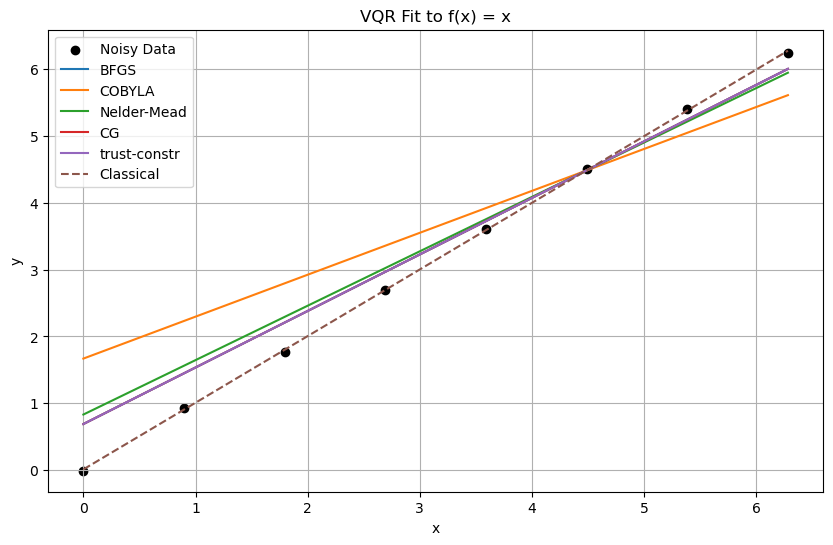

In [15]:

import numpy as np
import matplotlib.pyplot as plt
import math
import random
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize

# Quantum inner product estimation function
def inner_prod(vec1, vec2):
    # Check if both input vectors have the same length
    if len(vec1) != len(vec2):
        # If not, raise an error
        raise ValueError('Vectors must be the same length')
    
    # Get the length of the vectors
    N = len(vec1)
    # Calculate how many qubits we need (log base 2 of N, rounded up)
    nqubits = math.ceil(np.log2(N))
    # Combine both vectors into one and normalize by sqrt(2)
    vec = np.concatenate((vec1, vec2)) / np.sqrt(2)
    
    # Create a quantum circuit with nqubits + 1 qubits
    circ = QuantumCircuit(nqubits + 1)
    # Initialize the quantum state with our combined vector
    circ.initialize(vec, range(nqubits + 1))
    # Apply a Hadamard gate to the last qubit
    circ.h(nqubits)
    
    # Get the quantum state vector from the circuit
    state = Statevector.from_instruction(circ)
    # Extract only the real parts of the amplitude values
    real_amps = np.real(state.data)
    # Sum the squares of the first N real amplitudes
    m_sum = sum(real_amps[l]**2 for l in range(N))
    # Return the quantum inner product estimate
    return 2 * m_sum - 1


# Global variables
order = 1  # Order of polynomial we want to fit (degree 3 = cubic)
N = 8      # Number of data points to generate

# Cost function that measures how good our polynomial fit is
def calculate_cost_function_n(parameters):
    # Start with first parameter times a vector of ones (constant term)
    ansatz = parameters[0] * np.ones_like(x)
    # Add higher order terms: parameter[i] * x^i
    for i in range(1, len(parameters)):
        ansatz += parameters[i] * x**i
    
    # Calculate the norm (length) of our polynomial prediction
    ansatz_norm = np.linalg.norm(ansatz)
    # Normalize the prediction to unit length
    ansatz_unit = ansatz / ansatz_norm
    # Calculate quantum similarity between true data and our prediction
    y_ansatz = ansatz_norm / ynorm * inner_prod(y, ansatz_unit)
    # Return squared error (we want to minimize this)
    return (1 - y_ansatz) ** 2

# Function to generate noisy data from a mathematical function
def generate_data(func, noise=0.05):
    # Create N evenly spaced points from 0 to 2π
    x = np.linspace(0, 2*np.pi, N)
    # Apply the function and add random noise
    y = func(x) + np.random.uniform(-noise, noise, N)
    # Return both x and y data
    return x, y

# Function to test multiple optimization methods
def run_optimizers(cost_fn, x0):
    # List of optimization methods to test
    methods = ["BFGS", "COBYLA", "Nelder-Mead", "CG", "trust-constr"]
    # Dictionary to store results from each method
    results = {}
    
    # Try each optimization method
    for method in methods:
        try:
            # Run the optimization with current method
            result = minimize(cost_fn, x0=x0, method=method,
                              options={'maxiter': 200}, tol=1e-6)
            # Store the result
            results[method] = result
        except Exception as e:
            # If optimization fails, store error message
            results[method] = f"Failed: {e}"
    # Return all results
    return results

# Function to evaluate polynomial with given coefficients
def evaluate_fit(xfit, coeffs):
    # Start with zeros
    yfit = np.zeros_like(xfit)
    # Add each term: coefficient * x^power
    for i, a in enumerate(coeffs):
        yfit += a * xfit**i
    # Return the polynomial evaluation
    return yfit

# Main function to run VQR (Variational Quantum Regression) for a given function
def run_vqr_for_function(func, label):
    # Declare global variables so we can modify them
    global x, y, ynorm
    
    # Generate noisy data from the input function
    x, y = generate_data(func)
    # Calculate norm of y data for normalization
    ynorm = np.linalg.norm(y)
    # Normalize y data to unit length
    y = y / ynorm
    
    # Create random initial guess for polynomial coefficients
    x0 = [random.uniform(0, 2) for _ in range(order + 1)]
    
    # Run all optimizers on our cost function
    results = run_optimizers(calculate_cost_function_n, x0)
    
    # === Evaluation printout ===
    # Print header for this function's results
    print(f"\nResults for {label}")
    # Dictionary to store MSE scores for comparison
    mse_scores = {}
    
    # Loop through each optimization method's results
    for method, result in results.items():
        # Check if this method failed (result is error string)
        if isinstance(result, str):
            # Print the failure message
            print(f"{method:12s} : {result}")
            # Skip to next method
            continue
        
        # Extract the optimized coefficients
        coeffs = result.x
        # Evaluate our polynomial fit at the data points
        yfit = evaluate_fit(x, coeffs)
        # Calculate Mean Squared Error (scaled back to original units)
        mse = np.mean((y * ynorm - yfit)**2)
        # Store MSE for this method
        mse_scores[method] = mse
        # Print results for this method
        print(f"{method:12s} : Final cost = {result.fun:.4e}, MSE = {mse:.4e}")
    
    # Highlight best optimizer
    # Check if we have any successful results
    if mse_scores:
        # Find method with lowest MSE
        best_method = min(mse_scores, key=mse_scores.get)
        # Print the winner
        print(f" Best optimizer for {label}: {best_method} (MSE = {mse_scores[best_method]:.4e})")
    
    # === Plotting ===
    # Create fine grid for smooth plotting
    xfit = np.linspace(np.min(x), np.max(x), 100)
    # Create new figure with specified size
    plt.figure(figsize=(10, 6))
    # Plot the original noisy data points
    plt.scatter(x, y * ynorm, label="Noisy Data", color='black')
    
    # Plot fit from each optimization method
    for method, result in results.items():
        # Skip failed methods
        if isinstance(result, str):
            continue
        # Get optimized coefficients
        coeffs = result.x
        # Evaluate polynomial on fine grid
        yfit = evaluate_fit(xfit, coeffs)
        # Plot this method's fit
        plt.plot(xfit, yfit, label=method)
    
    # Classical baseline comparison
    # Use standard polynomial fitting as reference
    classical_fit = np.polyfit(x, y * ynorm, order)[::-1]  # Reverse for our format
    # Evaluate classical fit
    y_classical = evaluate_fit(xfit, classical_fit)
    # Plot classical fit with dashed line
    plt.plot(xfit, y_classical, label="Classical", linestyle='dashed')
    
    # Add plot labels and formatting
    plt.title(f"VQR Fit to {label}")  
    plt.xlabel("x")                   
    plt.ylabel("y")                   
    plt.legend()                      
    plt.grid(True)                    

# Run VQR analysis for linear function f(x) = x
run_vqr_for_function(lambda t: t, "f(x) = x")



Results for f(x) = x^2
BFGS         : Final cost = 2.3050e-16, MSE = 2.6319e+00
COBYLA       : Final cost = 3.0220e-11, MSE = 2.0795e+00
Nelder-Mead  : Final cost = 3.6804e-16, MSE = 1.3722e+00
CG           : Final cost = 2.3050e-16, MSE = 2.6319e+00
trust-constr : Final cost = 2.9156e-16, MSE = 2.6319e+00
 Best optimizer for f(x) = x^2: Nelder-Mead (MSE = 1.3722e+00)


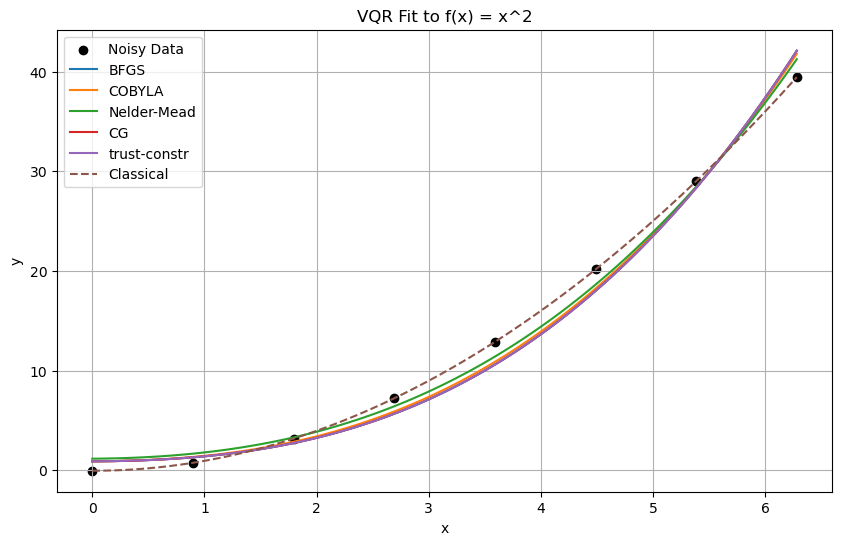

In [14]:

import numpy as np
import matplotlib.pyplot as plt
import math
import random
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize

# Quantum inner product estimation function
def inner_prod(vec1, vec2):
    # Check if both input vectors have the same length
    if len(vec1) != len(vec2):
        # If not, raise an error
        raise ValueError('Vectors must be the same length')
    
    # Get the length of the vectors
    N = len(vec1)
    # Calculate how many qubits we need (log base 2 of N, rounded up)
    nqubits = math.ceil(np.log2(N))
    # Combine both vectors into one and normalize by sqrt(2)
    vec = np.concatenate((vec1, vec2)) / np.sqrt(2)
    
    # Create a quantum circuit with nqubits + 1 qubits
    circ = QuantumCircuit(nqubits + 1)
    # Initialize the quantum state with our combined vector
    circ.initialize(vec, range(nqubits + 1))
    # Apply a Hadamard gate to the last qubit
    circ.h(nqubits)
    
    # Get the quantum state vector from the circuit
    state = Statevector.from_instruction(circ)
    # Extract only the real parts of the amplitude values
    real_amps = np.real(state.data)
    # Sum the squares of the first N real amplitudes
    m_sum = sum(real_amps[l]**2 for l in range(N))
    # Return the quantum inner product estimate
    return 2 * m_sum - 1


# Global variables
order = 3  # Order of polynomial we want to fit (degree 3 = cubic)
N = 8      # Number of data points to generate

# Cost function that measures how good our polynomial fit is
def calculate_cost_function_n(parameters):
    # Start with first parameter times a vector of ones (constant term)
    ansatz = parameters[0] * np.ones_like(x)
    # Add higher order terms: parameter[i] * x^i
    for i in range(1, len(parameters)):
        ansatz += parameters[i] * x**i
    
    # Calculate the norm (length) of our polynomial prediction
    ansatz_norm = np.linalg.norm(ansatz)
    # Normalize the prediction to unit length
    ansatz_unit = ansatz / ansatz_norm
    # Calculate quantum similarity between true data and our prediction
    y_ansatz = ansatz_norm / ynorm * inner_prod(y, ansatz_unit)
    # Return squared error (we want to minimize this)
    return (1 - y_ansatz) ** 2

# Function to generate noisy data from a mathematical function
def generate_data(func, noise=0.05):
    # Create N evenly spaced points from 0 to 2π
    x = np.linspace(0, 2*np.pi, N)
    # Apply the function and add random noise
    y = func(x) + np.random.uniform(-noise, noise, N)
    # Return both x and y data
    return x, y

# Function to test multiple optimization methods
def run_optimizers(cost_fn, x0):
    # List of optimization methods to test
    methods = ["BFGS", "COBYLA", "Nelder-Mead", "CG", "trust-constr"]
    # Dictionary to store results from each method
    results = {}
    
    # Try each optimization method
    for method in methods:
        try:
            # Run the optimization with current method
            result = minimize(cost_fn, x0=x0, method=method,
                              options={'maxiter': 200}, tol=1e-6)
            # Store the result
            results[method] = result
        except Exception as e:
            # If optimization fails, store error message
            results[method] = f"Failed: {e}"
    # Return all results
    return results

# Function to evaluate polynomial with given coefficients
def evaluate_fit(xfit, coeffs):
    # Start with zeros
    yfit = np.zeros_like(xfit)
    # Add each term: coefficient * x^power
    for i, a in enumerate(coeffs):
        yfit += a * xfit**i
    # Return the polynomial evaluation
    return yfit

# Main function to run VQR (Variational Quantum Regression) for a given function
def run_vqr_for_function(func, label):
    # Declare global variables so we can modify them
    global x, y, ynorm
    
    # Generate noisy data from the input function
    x, y = generate_data(func)
    # Calculate norm of y data for normalization
    ynorm = np.linalg.norm(y)
    # Normalize y data to unit length
    y = y / ynorm
    
    # Create random initial guess for polynomial coefficients
    x0 = [random.uniform(0, 2) for _ in range(order + 1)]
    
    # Run all optimizers on our cost function
    results = run_optimizers(calculate_cost_function_n, x0)
    
    # === Evaluation printout ===
    # Print header for this function's results
    print(f"\nResults for {label}")
    # Dictionary to store MSE scores for comparison
    mse_scores = {}
    
    # Loop through each optimization method's results
    for method, result in results.items():
        # Check if this method failed (result is error string)
        if isinstance(result, str):
            # Print the failure message
            print(f"{method:12s} : {result}")
            # Skip to next method
            continue
        
        # Extract the optimized coefficients
        coeffs = result.x
        # Evaluate our polynomial fit at the data points
        yfit = evaluate_fit(x, coeffs)
        # Calculate Mean Squared Error (scaled back to original units)
        mse = np.mean((y * ynorm - yfit)**2)
        # Store MSE for this method
        mse_scores[method] = mse
        # Print results for this method
        print(f"{method:12s} : Final cost = {result.fun:.4e}, MSE = {mse:.4e}")
    
    # Highlight best optimizer
    # Check if we have any successful results
    if mse_scores:
        # Find method with lowest MSE
        best_method = min(mse_scores, key=mse_scores.get)
        # Print the winner
        print(f" Best optimizer for {label}: {best_method} (MSE = {mse_scores[best_method]:.4e})")
    
    # === Plotting ===
    # Create fine grid for smooth plotting
    xfit = np.linspace(np.min(x), np.max(x), 100)
    # Create new figure with specified size
    plt.figure(figsize=(10, 6))
    # Plot the original noisy data points
    plt.scatter(x, y * ynorm, label="Noisy Data", color='black')
    
    # Plot fit from each optimization method
    for method, result in results.items():
        # Skip failed methods
        if isinstance(result, str):
            continue
        # Get optimized coefficients
        coeffs = result.x
        # Evaluate polynomial on fine grid
        yfit = evaluate_fit(xfit, coeffs)
        # Plot this method's fit
        plt.plot(xfit, yfit, label=method)
    
    # Classical baseline comparison
    # Use standard polynomial fitting as reference
    classical_fit = np.polyfit(x, y * ynorm, order)[::-1]  # Reverse for our format
    # Evaluate classical fit
    y_classical = evaluate_fit(xfit, classical_fit)
    # Plot classical fit with dashed line
    plt.plot(xfit, y_classical, label="Classical", linestyle='dashed')
    
    # Add plot labels and formatting
    plt.title(f"VQR Fit to {label}")  
    plt.xlabel("x")                   
    plt.ylabel("y")                   
    plt.legend()                      
    plt.grid(True)                    


# Run VQR analysis for quadratic function f(x) = x^2
run_vqr_for_function(lambda t: t**2, "f(x) = x^2")